# Capstone Modeling
**Project:** Predicting Long-Run Home Price Appreciation Across U.S. Housing Markets  
**Notebook:** 04: Statistical Analysis and Machine Learning Models  

This notebook executes the full analytical pipeline:

**Part 1: Inferential Statistics**  
Pearson correlation test: Is population growth rate significantly correlated with appreciation?

**Part 2: Supervised Regression Models**  
- Linear Regression (baseline)
- Random Forest Regressor (primary model)

**Part 3: Evaluation and Interpretation**  
- R², RMSE, MAE for both models
- Feature importance ranking (Random Forest)
- Predicted vs. actual plot

All results and figures are saved for use in Task 2 and Task 3.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

os.makedirs('data/figures', exist_ok=True)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

panel = pd.read_csv('data/processed/panel_dataset.csv')

PREDICTOR_COLS = [
    'pop_growth_rate', 'unemployment_rate', 'poverty_rate',
    'median_income', 'pct_bachelors_plus', 'vacancy_rate',
    'homeownership_rate', 'mortgage_rate'
]
PREDICTOR_LABELS = [
    'Population Growth Rate', 'Unemployment Rate', 'Poverty Rate',
    'Median Income', "% Bachelor's+", 'Vacancy Rate',
    'Homeownership Rate', 'Mortgage Rate'
]

X = panel[PREDICTOR_COLS].copy()
y = panel['appreciation_rate'].copy()

print(f'Dataset: {X.shape[0]:,} observations, {X.shape[1]} predictors')
print(f'Outcome (appreciation_rate): mean={y.mean():.2f}%, std={y.std():.2f}%')

Dataset: 1,178 observations, 8 predictors
Outcome (appreciation_rate): mean=7.08%, std=5.17%


---
## Part 1: Pearson Correlation Test

**H₀ (null hypothesis):** There is no significant linear correlation between population growth rate and
home price appreciation rate (ρ = 0)  
**H₁ (alternative hypothesis):** There is a significant positive linear correlation (ρ > 0)  
**α = 0.05**

In [21]:
# Pearson correlation test: population growth rate vs appreciation rate
corr_r, corr_p = stats.pearsonr(
    panel['pop_growth_rate'].dropna(),
    panel.loc[panel['pop_growth_rate'].notna(), 'appreciation_rate']
)

alpha = 0.05
print('=' * 55)
print('PEARSON CORRELATION TEST')
print('=' * 55)
print(f'Variables:     pop_growth_rate vs appreciation_rate')
print(f'n:             {panel["pop_growth_rate"].notna().sum():,}')
print(f'r (Pearson):   {corr_r:.4f}')
print(f'p-value:       {corr_p:.6f}')
print(f'alpha (α):     {alpha}')
print()
if corr_p < alpha:
    print(f'RESULT: p={corr_p:.6f} < α={alpha}')
    print('DECISION: Reject H₀.')
    print('CONCLUSION: There is sufficient evidence of a statistically significant')
    print(f'positive correlation (r={corr_r:.4f}) between population growth rate')
    print('and home price appreciation rate.')
else:
    print(f'RESULT: p={corr_p:.6f} ≥ α={alpha}')
    print('DECISION: Fail to reject H₀.')
    print('CONCLUSION: Insufficient evidence of a significant correlation.')

# Also run correlation test for all predictors
print()
print('Pearson r and p-value for ALL predictors vs appreciation_rate:')
print(f'{"Predictor":<25} {"r":>8} {"p-value":>12} {"Significant?":>14}')
print('-' * 63)
for col, label in zip(PREDICTOR_COLS, PREDICTOR_LABELS):
    valid = panel[[col, 'appreciation_rate']].dropna()
    r, p = stats.pearsonr(valid[col], valid['appreciation_rate'])
    sig = 'Yes' if p < 0.05 else 'No'
    print(f'{label:<25} {r:>8.4f} {p:>12.6f} {sig:>14}')

PEARSON CORRELATION TEST
Variables:     pop_growth_rate vs appreciation_rate
n:             1,178
r (Pearson):   0.0660
p-value:       0.023445
alpha (α):     0.05

RESULT: p=0.023445 < α=0.05
DECISION: Reject H₀.
CONCLUSION: There is sufficient evidence of a statistically significant
positive correlation (r=0.0660) between population growth rate
and home price appreciation rate.

Pearson r and p-value for ALL predictors vs appreciation_rate:
Predictor                        r      p-value   Significant?
---------------------------------------------------------------
Population Growth Rate      0.0660     0.023445            Yes
Unemployment Rate           0.0836     0.004072            Yes
Poverty Rate                0.0226     0.438645             No
Median Income              -0.0408     0.161697             No
% Bachelor's+              -0.0360     0.217571             No
Vacancy Rate                0.0352     0.227918             No
Homeownership Rate          0.0038     0.895870 

---
## Part 2: Train/Test Split

In [22]:
# 80/20 random split with fixed seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training set:  {X_train.shape[0]:,} observations ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:      {X_test.shape[0]:,} observations ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Random state:  42')

Training set:  942 observations (80%)
Test set:      236 observations (20%)
Random state:  42


---
## Part 3: Linear Regression: Baseline Model

In [23]:
# Linear regression with StandardScaler
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

lr_r2   = r2_score(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)

# Cross-validated R² (5-fold) for more robust estimate
lr_cv_r2 = cross_val_score(lr_pipeline, X, y, cv=5, scoring='r2').mean()

print('=' * 45)
print('LINEAR REGRESSION: BASELINE MODEL')
print('=' * 45)
print(f'R² (test set):       {lr_r2:.4f}')
print(f'R² (5-fold CV avg):  {lr_cv_r2:.4f}')
print(f'RMSE (test set):     {lr_rmse:.4f} percentage points')
print(f'MAE (test set):      {lr_mae:.4f} percentage points')

# Standardized coefficients
coefs = pd.Series(
    lr_pipeline.named_steps['model'].coef_,
    index=PREDICTOR_LABELS
).sort_values(key=abs, ascending=False)

print()
print('Standardized coefficients (magnitude = relative importance):')
print(coefs.round(4).to_string())

LINEAR REGRESSION: BASELINE MODEL
R² (test set):       0.1125
R² (5-fold CV avg):  0.0652
RMSE (test set):     5.4414 percentage points
MAE (test set):      4.1602 percentage points

Standardized coefficients (magnitude = relative importance):
Mortgage Rate            -2.2732
Median Income             2.0126
Poverty Rate              0.8775
% Bachelor's+            -0.6154
Population Growth Rate    0.4437
Homeownership Rate        0.4174
Unemployment Rate        -0.3415
Vacancy Rate              0.0273


---
## Part 4: Random Forest Regression: Primary Model

In [24]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_r2   = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)

# Cross-validated R²
rf_cv_r2 = cross_val_score(rf_model, X, y, cv=5, scoring='r2').mean()

print('=' * 45)
print('RANDOM FOREST: PRIMARY MODEL')
print('=' * 45)
print(f'R² (test set):       {rf_r2:.4f}')
print(f'R² (5-fold CV avg):  {rf_cv_r2:.4f}')
print(f'RMSE (test set):     {rf_rmse:.4f} percentage points')
print(f'MAE (test set):      {rf_mae:.4f} percentage points')
print(f'Benchmark (R² ≥ 0.50): {"PASSED" if rf_r2 >= 0.50 else "NOT MET"}')

# Feature importance
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=PREDICTOR_LABELS
).sort_values(ascending=False)

print()
print('Feature importance scores (sum = 1.0):')
for name, imp in feat_imp.items():
    bar = '█' * int(imp * 100)
    print(f'  {name:<28} {imp:.4f}  {bar}')

RANDOM FOREST: PRIMARY MODEL
R² (test set):       0.5776
R² (5-fold CV avg):  0.5598
RMSE (test set):     3.7540 percentage points
MAE (test set):      2.6893 percentage points
Benchmark (R² ≥ 0.50): PASSED

Feature importance scores (sum = 1.0):
  Mortgage Rate                0.3527  ███████████████████████████████████
  Population Growth Rate       0.1186  ███████████
  Unemployment Rate            0.1150  ███████████
  Vacancy Rate                 0.1086  ██████████
  Median Income                0.0780  ███████
  % Bachelor's+                0.0767  ███████
  Homeownership Rate           0.0765  ███████
  Poverty Rate                 0.0738  ███████


---
## Part 5: Model Comparison and Evaluation Figures

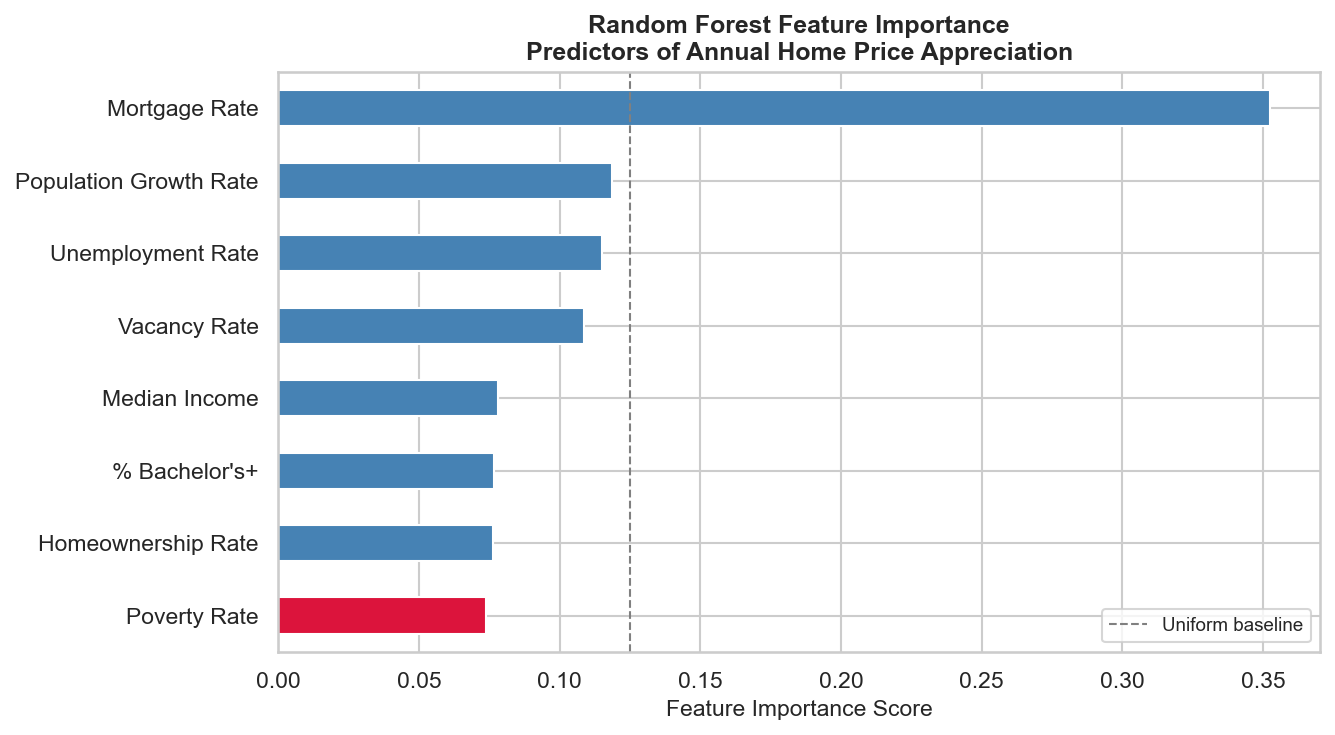

In [25]:
# Figure 6: Feature Importance Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['steelblue'] * len(feat_imp)
colors[0] = 'crimson'  # Highlight top predictor

feat_imp.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Random Forest Feature Importance\nPredictors of Annual Home Price Appreciation', fontsize=12, fontweight='bold')
ax.axvline(1/len(feat_imp), color='gray', linestyle='--', linewidth=1, label='Uniform baseline')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/figures/fig6_feature_importance.png')
plt.show()

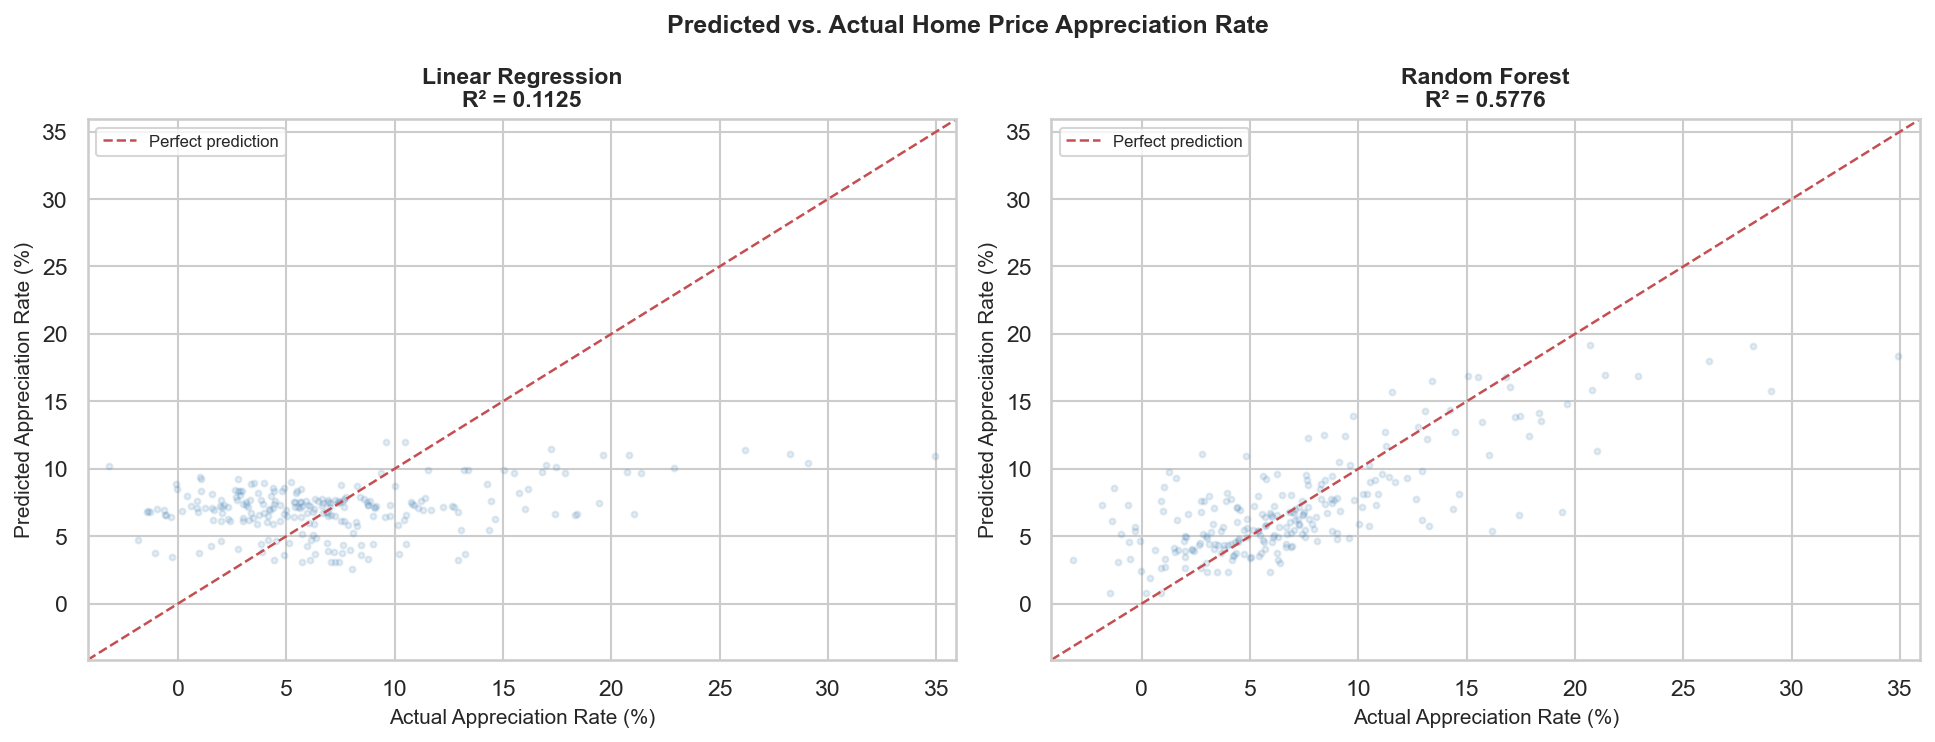

In [26]:
# Figure 7: Predicted vs Actual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

lims = [min(y_test.min(), lr_preds.min(), rf_preds.min()) - 1,
        max(y_test.max(), lr_preds.max(), rf_preds.max()) + 1]

for ax, preds, label, r2 in [
    (ax1, lr_preds, 'Linear Regression', lr_r2),
    (ax2, rf_preds, 'Random Forest',     rf_r2)
]:
    ax.scatter(y_test, preds, alpha=0.15, s=8, color='steelblue')
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Appreciation Rate (%)', fontsize=10)
    ax.set_ylabel('Predicted Appreciation Rate (%)', fontsize=10)
    ax.set_title(f'{label}\nR² = {r2:.4f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs. Actual Home Price Appreciation Rate', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/figures/fig7_predicted_vs_actual.png')
plt.show()

In [27]:
# Full results summary
print('=' * 60)
print('COMPLETE RESULTS SUMMARY')
print('=' * 60)
print()
print('PEARSON CORRELATION TEST')
print(f'  r = {corr_r:.4f},  p = {corr_p:.6f},  α = {alpha}')
print(f'  Null hypothesis rejected: {"Yes" if corr_p < alpha else "No"}')
print()
print('LINEAR REGRESSION (baseline)')
print(f'  R²   = {lr_r2:.4f}  (CV avg: {lr_cv_r2:.4f})')
print(f'  RMSE = {lr_rmse:.4f} percentage points')
print(f'  MAE  = {lr_mae:.4f} percentage points')
print()
print('RANDOM FOREST REGRESSION (primary)')
print(f'  R²   = {rf_r2:.4f}  (CV avg: {rf_cv_r2:.4f})')
print(f'  RMSE = {rf_rmse:.4f} percentage points')
print(f'  MAE  = {rf_mae:.4f} percentage points')
print(f'  Benchmark R² ≥ 0.50: {"PASSED" if rf_r2 >= 0.50 else "NOT MET"}')
print()
print('FEATURE IMPORTANCE RANKING (Random Forest)')
for rank, (name, imp) in enumerate(feat_imp.items(), 1):
    print(f'  {rank}. {name:<28} {imp:.4f} ({imp*100:.1f}%)')

COMPLETE RESULTS SUMMARY

PEARSON CORRELATION TEST
  r = 0.0660,  p = 0.023445,  α = 0.05
  Null hypothesis rejected: Yes

LINEAR REGRESSION (baseline)
  R²   = 0.1125  (CV avg: 0.0652)
  RMSE = 5.4414 percentage points
  MAE  = 4.1602 percentage points

RANDOM FOREST REGRESSION (primary)
  R²   = 0.5776  (CV avg: 0.5598)
  RMSE = 3.7540 percentage points
  MAE  = 2.6893 percentage points
  Benchmark R² ≥ 0.50: PASSED

FEATURE IMPORTANCE RANKING (Random Forest)
  1. Mortgage Rate                0.3527 (35.3%)
  2. Population Growth Rate       0.1186 (11.9%)
  3. Unemployment Rate            0.1150 (11.5%)
  4. Vacancy Rate                 0.1086 (10.9%)
  5. Median Income                0.0780 (7.8%)
  6. % Bachelor's+                0.0767 (7.7%)
  7. Homeownership Rate           0.0765 (7.6%)
  8. Poverty Rate                 0.0738 (7.4%)
